# 03MIAR - Algoritmos de optimización
## Actividad guiada 2

Autor del notebook: *David Álvarez Robles*

Autor de las actividades extra: *Ángel González De La Vara*

## Repositorios
https://github.com/angelgv95/MIAR_Algoritmos_Optimizacion/blob/main/AG2/03MIAR_AG2_Angel_Gonzalez_De_La_Vara.ipynb

https://colab.research.google.com/drive/1pIxW5TTlw25eKchxHtQtPBnyO6u-DhQi?usp=sharing

## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Comprender la utilidad y aplicar algoritmos dinámicos
- Comprender la utilidad y aplicar algoritmos de ramificación y poda
- Comprender la utilidad y aplicar el algoritmo de optimización por descenso de gradiente

## Programación dinámica - Problema del viaje por el río
- Se divide el problema en subproblemas más pequeños para poder usar las soluciones más adelante
- Si el problema verifica el principio de optimalidad de Bellman "en una secuencia óptima de decisiones, toda sub-secuencia es también óptima" esto funciona bien
- Guardar soluciones parciales + recursividad = complejidad

In [1]:
import math

i = float("inf")

tarifas = [
    [0, 5, 4, 3, i, i, i],
    [i, 0, i, 2, 3, i, 11],
    [i, i, 0, 1, i, 4, 10],
    [i, i, i, 0, 5, 6, 9],
    [i, i, i, i, 0, i ,4],
    [i, i, i, i, i, 0, 3],
    [i, i, i, i, i, i, 0]
]

# Función para obtener precios finales entre dos nodos y qué rutas seguir
def obtener_precios_y_rutas(tarifas):
    # Inicialización de tabla de precios y rutas (precios a infinito como peor caso)
    nodos = len(tarifas[0])
    precios = [[i]*nodos for i in [float("inf")]*nodos]
    ruta = [[i]*nodos for i in [""]*nodos]

    # Recorremos todos los caminos (desde "n" hasta un "n" superior -> Ej: 0 a 1, 0 a 2, 1 a 4... pero nunca de 1 a 0 o de 4 a 2)
    for i in range(nodos-1):
        for j in range(i+1,nodos):

            # Asumimos que el mínimo es la tarifa de un nodo a otro inicialmente
            minimo = tarifas[i][j]
            # Asumimos que la mejor ruta de un nodo a otro comienza en el nodo inicial (ej: 0,1 -> 0, 0,4 -> 0, 2,5 -> 2)
            ruta[i][j] = i

            # Recorremos posibles movimientos intermedios
            for k in range(i,j):
                #print(precios)
                #print(f"i: {i}, j: {j}, k: {k}, precios_ik: {precios[i][k]}, tarifas_kj: {tarifas[k][j]}")
                # Si el precio de ir de i a k más la tarifa de k a j es menor que la tarifa de i a j, nos quedamos con esa ruta
                if (precios[i][k] + tarifas[k][j] < minimo):
                    minimo = precios[i][k] + tarifas[k][j]
                    ruta[i][j] = k
                # Actualizamos precio de i a j como el mínimo (puede ser pasando por k)
                precios[i][j] = minimo

    # Retornamos tabla de precios y de rutas de un nodo a otro
    return precios, ruta

# Función que calcula la ruta óptima a seguir
def calcular_ruta(ruta, inicio, fin, resultado = []):
    # Si el nodo inicial es igual al final, devolvemos el nodo
    if inicio == fin:
        #print(f"{inicio}")
        resultado.append(inicio)
        return resultado
    # Si tengo que desplazarme, calculo recursivamente la ruta de inicio a final siguiendo la tabla de rutas
    else:
        #print(f"{fin}")
        resultado.append(fin)
        return calcular_ruta(ruta, inicio, ruta[inicio][fin])

precios, ruta = obtener_precios_y_rutas(tarifas)

for fila in precios:
  print(fila)
print("---")
for fila in ruta:
  print(fila)

desde=0
hasta=6
resultado = calcular_ruta(ruta, desde, hasta)
print("---")
print(f"Ruta a seguir: {resultado[::-1]}")

[inf, 5, 4, 3, 8, 8, 11]
[inf, inf, inf, 2, 3, 8, 7]
[inf, inf, inf, 1, 6, 4, 7]
[inf, inf, inf, inf, 5, 6, 9]
[inf, inf, inf, inf, inf, inf, 4]
[inf, inf, inf, inf, inf, inf, 3]
[inf, inf, inf, inf, inf, inf, inf]
---
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']
---
Ruta a seguir: [0, 2, 5, 6]


## Ramificación y poda - Problema de las tareas
- Se necesitan funciones auxiliares para calcular todo el grafo (árbol)
- Función para calcular costes de soluciones parciales (no completas)
- Función para calcular cota inferior (muy optimista, repitiendo tareas si es necesario aunque la poda sea peor)
- Función para crear hijos e ir construyendo las soluciones
- Función para ramificar nodos y podar

In [2]:
import itertools
import math

costes = [
    [11,12,18,40],
    [14,15,13,22],
    [11,17,19,23],
    [17,14,20,28]
]

for s in itertools.permutations(range(len(costes))):
  print(s)

(0, 1, 2, 3)
(0, 1, 3, 2)
(0, 2, 1, 3)
(0, 2, 3, 1)
(0, 3, 1, 2)
(0, 3, 2, 1)
(1, 0, 2, 3)
(1, 0, 3, 2)
(1, 2, 0, 3)
(1, 2, 3, 0)
(1, 3, 0, 2)
(1, 3, 2, 0)
(2, 0, 1, 3)
(2, 0, 3, 1)
(2, 1, 0, 3)
(2, 1, 3, 0)
(2, 3, 0, 1)
(2, 3, 1, 0)
(3, 0, 1, 2)
(3, 0, 2, 1)
(3, 1, 0, 2)
(3, 1, 2, 0)
(3, 2, 0, 1)
(3, 2, 1, 0)


In [3]:
def fuerza_bruta(costes):

    optimo = float("inf")

    for s in itertools.permutations(range(len(costes))):
        coste = sum(costes[i][s[i]] for i in range(len(costes))) # Acumulo costes de cada agente
        if (coste < optimo):
            tareas, optimo = s, coste

    return tareas, optimo

tareas, optimo = fuerza_bruta(costes)
print(f"Obtenida mejor solución {tareas} con coste {optimo} por fuerza bruta")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 por fuerza bruta


In [4]:
def coste_parcial(solucion, costes):
    coste = 0

    for i in range(len(solucion)):
        coste += costes[i][solucion[i]]

    return coste

coste = coste_parcial((0,1),costes) # 11 + 15 = 26
print(coste)

26


In [5]:
def cota_inferior(solucion, costes):
    # Calculo el coste parcial de la solución dada
    coste = coste_parcial(solucion,costes)

    # Calculo coste mínimo de opciones restantes no usadas permitiendo reutilización por sencillez (relajación = menos poda)
    no_usadas = set(range(len(costes)))-set(solucion)

    for i in range(len(solucion),len(costes)):
        coste += min([costes[i][j] for j in no_usadas])

    return coste

CI = cota_inferior((0,1),costes)
print(CI)

65


In [6]:
# def cota_superior(solucion, costes):
#     # Calculo el coste parcial de la solución dada
#     coste = coste_parcial(solucion,costes)

#     # Calculo coste máximo de opciones restantes no usadas
#     no_usadas = set(range(len(costes)))-set(solucion)

#     for i in range(len(solucion),len(costes)):
#         coste += max([costes[i][j] for j in no_usadas])

#     return coste

# CS = cota_superior((0,1),costes)
# print(CS)

In [7]:
# Función para crear las ramas del árbol
def crear_hijos(solucion, dimension):
  hijos = []
  for i in range(dimension):
    if i not in solucion:
      hijos.append({'s':solucion + (i,)})
  return hijos

crear_hijos((1,2),4)

[{'s': (1, 2, 0)}, {'s': (1, 2, 3)}]

In [8]:
def ramificacion_y_poda(costes):

    dimension = len(costes)

    # Inicializo solución a vacío con el peor coste posible
    mejor_solucion = tuple(i for i in range(dimension))
    mejor_coste = coste_parcial(mejor_solucion,costes)

    # Creo un array de nodos y lo inicializo con una solución vacía (para comenzar por algo)
    nodos = []
    nodos.append({'s':(), 'ci':cota_inferior((),costes)})

    # Llevo cuenta de iteraciones por debugging
    iteracion = 0

    # Mientras haya nodos por explorar, aplico ramificación y poda
    while(nodos):
        # Cojo el nodo más prometedor (menor cota inferior, aunque esto luego puede ser "peor" a posteriori)
        nodo = min(nodos, key=lambda x: x['ci'])

        # Ramifico el nodo para obtener sus hijos
        hijos = crear_hijos(nodo['s'],dimension)

        # Para cada hijo, hago el procesamiento adecuado antes de decidir si es solución completa o un nuevo nodo
        for hijo in hijos:

            # Si la dimensión de la solución es igual a la dimensión de costes, es una solución final
            if (len(hijo['s']) == dimension):
                # Calculo el coste de la solución obtenida en el árbol
                coste = coste_parcial(hijo['s'],costes)
                # Si el coste es mejor, me lo quedo como solución
                if (coste < mejor_coste):
                    mejor_solucion = hijo['s']
                    mejor_coste = coste

            # Si la dimensión de la solución no es igual a la dimensión de costes, aplico poda
            else:
                # Calculo cota inferior del hijo
                cota_inferior_hijo = cota_inferior(hijo['s'], costes)
                # Si la cota inferior es menor que el mejor coste, lo añado a la lista de nodos a actualizar
                # Si la cota inferior fuera mayor, no tiene sentido porque no puede mejorar mi solución -> Poda
                if (cota_inferior_hijo <= mejor_coste):
                    nodos.append({'s':hijo['s'], 'ci':cota_inferior_hijo})
                #else:
                    #print(mejor_coste)
                    #print(f"Nodo eliminado: {hijo['s']} con cota inferior {cota_inferior_hijo}")

        # Elimino el nodo ya mirado
        nodos.remove(nodo)

        # Llevo la cuenta de las iteraciones que hago
        iteracion += 1

    return iteracion, mejor_solucion, mejor_coste

iteraciones, mejor_solucion, mejor_coste = ramificacion_y_poda(costes)
print(f"Obtenida mejor solución {mejor_solucion} con coste {mejor_coste} en {iteraciones} iteraciones")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 en 17 iteraciones


## Descenso del gradiente - Optimización de funciones
- Se lleva a cabo una optimización basada en el método del descenso de gradiente
- Se calcula el vector de derivadas parciales y se minimiza la función objetivo actualizando los nuevos puntos (ver figura)

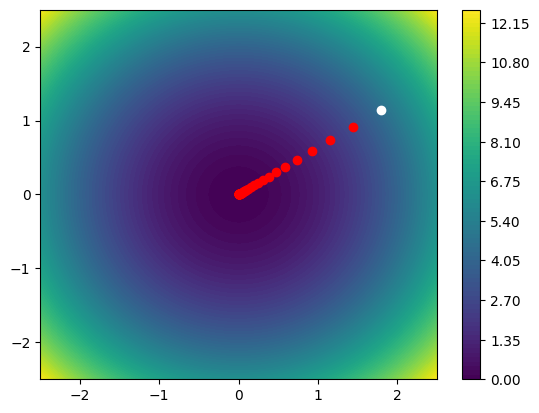

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

f = lambda X : X[0]**2 + X[1]**2
df = lambda X : [2*X[0] , 2*X[1]]

resolucion = 100
rango = 2.5
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros([resolucion, resolucion])

for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[ix,iy] = f([x,y])

plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

P = [random.uniform(-2,2), random.uniform(-2,2)]
plt.plot(P[0],P[1],"o",c="white")

tasa_aprendizaje = 0.1
for _ in range(500):
    grad = df(P)
    P[0], P[1] = P[0] - tasa_aprendizaje*grad[0], P[1] - tasa_aprendizaje*grad[1]
    plt.plot(P[0],P[1],"o",c="red")

## Actividades extra
- Ramificación y poda
  - Generar matrices con valores aleatorios de mayores dimensiones (5,6,7,…) y ejecutar ambos algoritmos.
  - ¿A partir de que dimensión el algoritmo por fuerza bruta deja de ser una opción?
  - ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda también deja de ser una opción válida?

El algoritmo de fuerza bruta aplicado a este problema tiene una complejidad O(n!), siendo n la dimensión del problema (número de agentes y de tareas).

Es importante destacar que el algoritmo de **Ramificación y poda también tiene una complejidad O(n!) en el peor de los casos**. Sin embargo, en la mayoría de los casos prácticos este algoritmo suele resolver el problema más rápido que el algoritmo de fuerza bruta porque poda muchas ramas, aunque esto depende de la distribución de los datos en la matriz de costes y tiene un componente aleatorio.

A continuación se realiza una evaluación del número de iteraciones y el tiempo de ejecución de cada algoritmo en función de la dimensión n del problema.

Resolviendo para una matriz de 5 x 5...
Fuerza bruta: obtenida mejor solución (1, 2, 0, 3, 4) con coste 49 en 120 iteraciones
Ramificación y poda: obtenida mejor solución (1, 2, 0, 3, 4) con coste 49 en 15 iteraciones

Resolviendo para una matriz de 6 x 6...
Fuerza bruta: obtenida mejor solución (3, 0, 1, 5, 4, 2) con coste 106 en 720 iteraciones
Ramificación y poda: obtenida mejor solución (3, 0, 1, 5, 4, 2) con coste 106 en 21 iteraciones

Resolviendo para una matriz de 7 x 7...
Fuerza bruta: obtenida mejor solución (6, 5, 4, 0, 3, 1, 2) con coste 233 en 5040 iteraciones
Ramificación y poda: obtenida mejor solución (6, 5, 4, 0, 3, 1, 2) con coste 233 en 250 iteraciones

Resolviendo para una matriz de 8 x 8...
Fuerza bruta: obtenida mejor solución (4, 3, 1, 6, 2, 5, 7, 0) con coste 175 en 40320 iteraciones
Ramificación y poda: obtenida mejor solución (4, 3, 1, 6, 2, 5, 7, 0) con coste 175 en 199 iteraciones

Resolviendo para una matriz de 9 x 9...
Fuerza bruta: obtenida mejor solución

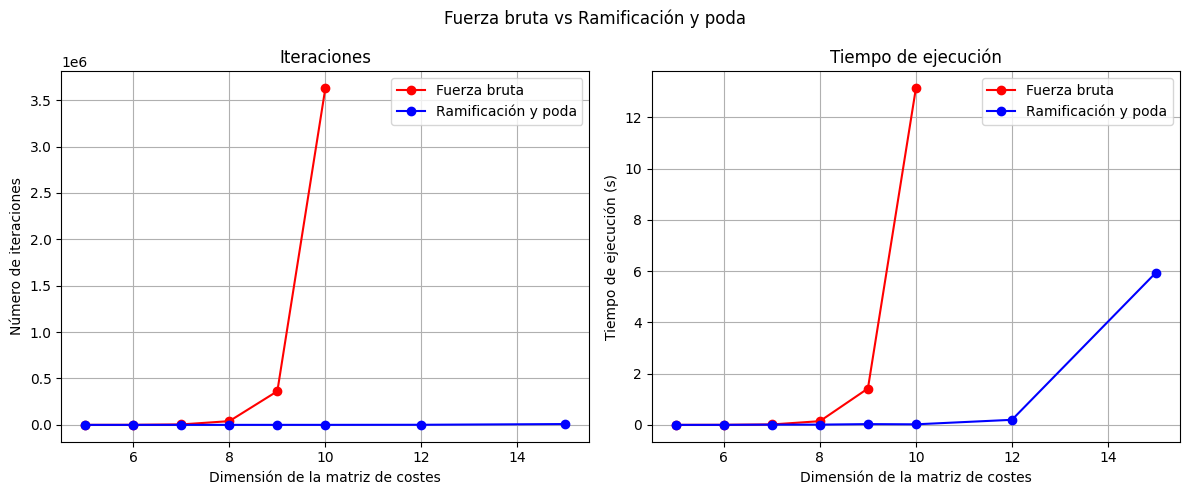

In [10]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

# En primer lugar se define una lista con las diferentes dimensiones de la matriz cuadrada de costes que van a evaluarse
n = [5, 6, 7, 8, 9, 10, 12, 15]

# No queremos evaluar el algoritmo de fuerza bruta para todos los casos en n porque llevaría demasiado tiempo
# Por lo tanto, definimos hasta dónde queremos evaluar la fuerza bruta
lim_fb = 10

# Inicializamos las listas que contendrán el número de iteraciones necesarias y el tiempo necesario para encontrar la solución en cada caso
# Nótese que el número de iteraciones que el algoritmo de fuerza bruta necesita para una dimensión del problema dada es conocido (factorial), por lo que se define directamente
iter_fb = [math.factorial(ni) for ni in n if ni <= lim_fb]
iter_rp = []
tiempo_fb = []
tiempo_rp = []

# Evaluamos todos los casos de dimensión del problema planteados
for ni in n:

  # Generamos la matriz de costes con valores aleatorios y las dimensiones especificadas
  costes = np.random.randint(0, 101, (ni, ni))

  print(f'Resolviendo para una matriz de {ni} x {ni}...')

  # Resolvemos el problema por fuerza bruta, midiendo el tiempo que tarda en ejecutarse el algoritmo
  if ni <= lim_fb:
    inicio = time.time()
    tareas, optimo = fuerza_bruta(costes)
    final = time.time()
    tiempo_fb.append(final - inicio)
    print(f"Fuerza bruta: obtenida mejor solución {tareas} con coste {optimo} en {math.factorial(ni)} iteraciones")

  # Resolvemos el problema mediante Ramificación y poda, midiendo el tiempo que tarda en ejecutarse el algoritmo
  inicio = time.time()
  iteraciones, mejor_solucion, mejor_coste = ramificacion_y_poda(costes)
  final = time.time()
  tiempo_rp.append(final - inicio)
  iter_rp.append(iteraciones)
  print(f"Ramificación y poda: obtenida mejor solución {mejor_solucion} con coste {mejor_coste} en {iteraciones} iteraciones\n")

# Mostramos los resultados obtenidos de número de iteraciones y tiempo de ejecución con cada método
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(n[0:len(iter_fb)], iter_fb, c='red', marker='o')
ax1.plot(n, iter_rp, c='blue', marker='o')
ax1.set_xlabel('Dimensión de la matriz de costes')
ax1.set_ylabel('Número de iteraciones')
ax1.set_title('Iteraciones')
ax1.legend(['Fuerza bruta', 'Ramificación y poda'])
ax1.grid(True)

ax2.plot(n[0:len(tiempo_fb)], tiempo_fb, c='red', marker='o')
ax2.plot(n, tiempo_rp, c='blue', marker='o')
ax2.set_xlabel('Dimensión de la matriz de costes')
ax2.set_ylabel('Tiempo de ejecución (s)')
ax2.set_title('Tiempo de ejecución')
ax2.legend(['Fuerza bruta', 'Ramificación y poda'])
ax2.grid(True)

fig.suptitle('Fuerza bruta vs Ramificación y poda')
plt.tight_layout()
plt.show()

Los resultados muestran que no hay una gran diferencia apreciable entre los dos algoritmos para una dimensión del problema de hasta 8. Evidentemente, si hiciésemos zoom veríamos que el algoritmo de Ramificación y poda requiere menos iteraciones y menos tiempo también para los casos con n <= 8, pero se considera que las diferencias no son significativas desde un punto de vista práctico.

Sin embargo, para valores de n mayores que 8 los dos algoritmos empiezan a mostrar diferencias significativas en sus resultados, con el algoritmo de fuerza bruta divergiendo en número de iteraciones y tiempo de ejecución. El algoritmo de Ramificación y poda no presenta un incremento explosivo de las iteraciones y el tiempo de ejecución se mantiene contenido hasta n = 15, donde se acerca al tiempo de ejecución del algoritmo de fuerza bruta para n = 10. 

Respecto a las preguntas del ejercicio, en este caso en concreto se recomendaría no utilizar el algoritmo de fuerza bruta para valores de n mayores que 8. Respecto al algoritmo de Ramificación y poda, no se recomienda su uso para n mayores que 12. Se recuerda que en el peor de los casos el algoritmo de Ramificación y poda presenta una complejidad factorial y nada asegura que el algoritmo consiga podar muchas ramas, por lo que debería evitarse su uso para valores de n relativamente grandes aunque suela presentar mejores resultados que la fuerza bruta.

Es importante destacar que estas conclusiones no son absolutas y que se han definido de forma completamente arbitraria, basándose en la comparación entre los resultados de ambos algoritmos. El uso de estos algoritmos para valores de n superiores a los recomendados es completamente posible en función del caso de aplicación y sus requisitos.

Por último, nótese que el tiempo de ejecución se ha usado en este análisis como una métrica orientativa para comparar ambos algoritmos desde un punto de vista físico. Sin embargo, este resultado dependerá del hardware y el estado del ordenador en el momento de la ejecución.

- Descenso de gradiente
  - Minimizar la función sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - E^y)

Para resolver este problema se parte del código usado en el ejercicio anterior sobre el descenso del gradiente y se le aplican una serie de modificaciones para adaptarlo a este ejercicio.

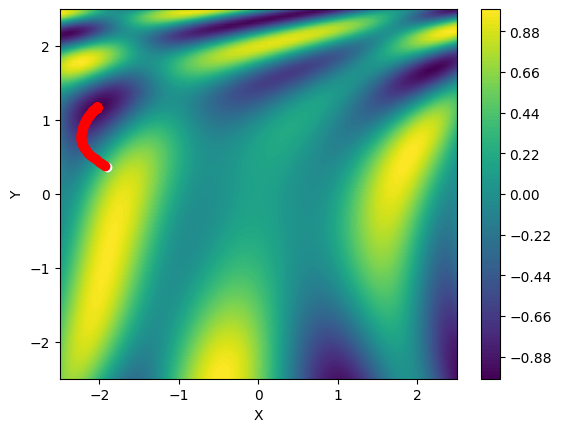

In [11]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

# Se define la función f que se quiere minimizar
f = lambda X : math.sin(0.5*X[0]**2 - 0.25*X[1]**2 + 3)*math.cos(2*X[0] + 1 - math.exp(X[1]))

# Se definen las derivadas parciales de la función f, df = [df/dX[0], df/dX[1]], obtenidas analíticamente aplicando las propiedades de las derivadas
df = lambda X : [X[0]*math.cos(0.5*X[0]**2 - 0.25*X[1]**2 + 3)*math.cos(2*X[0] + 1 - math.exp(X[1])) - 2*math.sin(2*X[0] + 1 - math.exp(X[1]))*math.sin(0.5*X[0]**2 - 0.25*X[1]**2 + 3),
                  -0.5*X[1]*math.cos(0.5*X[0]**2 - 0.25*X[1]**2 + 3)*math.cos(2*X[0] + 1 - math.exp(X[1])) + math.exp(X[1])*math.sin(2*X[0] + 1 - math.exp(X[1]))*math.sin(0.5*X[0]**2 - 0.25*X[1]**2 + 3)]

# Usamos la misma malla de puntos que en el ejercicio anterior
resolucion = 100
rango = 2.5
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros([resolucion, resolucion])

# Evaluamos la función a minimizar en cada punto de la malla
for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[ix,iy] = f([x,y])

# Creamos el gráfico de la función f. Nótese que Z está transpuesta para que visualmente los ejes de este gráfico sean X en horizontal e Y en vertical
plt.contourf(X, Y, Z.T, resolucion)
plt.colorbar()
plt.ylabel('Y')
plt.xlabel('X')

# Inicializamos el punto P de partida para el algoritmo de descenso del gradiente
P = [random.uniform(-2,2), random.uniform(-2,2)]

# Se plotea este punto de partida como un punto blanco
plt.plot(P[0],P[1],"o",c="white")

# Definimos de forma arbitraria la tasa de aprendizaje
tasa_aprendizaje = 0.01

# Se inicia el algoritmo del descenso del gradiente. Se han definido 500 iteraciones de forma arbitraria para ver la trayectoria del punto en la gráfica
for _ in range(500):
    # Se calcula el gradiente de la función en el punto P
    grad = df(P)
    # Se aplica el descenso del gradiente, actualizando P
    P[0], P[1] = P[0] - tasa_aprendizaje*grad[0], P[1] - tasa_aprendizaje*grad[1]
    # Se plotea el nuevo punto P después de su actualización
    plt.plot(P[0],P[1],"o",c="red")